In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Neural Network Project/Lab Assignment 5/Metro_Interstate_Traffic_Volume.csv')

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
df.shape

(48204, 9)

In [5]:
df.isna().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [6]:
# Fill NaN values in holiday column
df['holiday'] = df['holiday'].fillna(0)

# Convert holiday into binary values
df['holiday'] = df['holiday'].apply(lambda x: 1 if x != 0 else 0)

In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['weekend'] = (df['day_of_week'] >= 5).astype(int)

# Drop unnecessary columns
df = df.drop(columns=['date_time', 'weather_description'])

In [8]:
categorical_features = ['holiday', 'weather_main']

df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [9]:
scaler = MinMaxScaler()

continuous_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day_of_week',
    'month'
]

df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [10]:
SEQ_LEN = 48
TARGET = 'traffic_volume'

features = df.drop(columns=[TARGET]).values
target = df[TARGET].values

X = []
y = []

for i in range(SEQ_LEN, len(df)):
    X.append(features[i-SEQ_LEN:i])
    y.append(target[i])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (48156, 48, 19)
y Shape: (48156,)


In [11]:
y_scaler = MinMaxScaler()

y_scaled = y_scaler.fit_transform(y.reshape(-1,1))

In [12]:
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

# Training Data
X_train = X[:train_size]
y_train = y_scaled[:train_size]

# Validation Data
X_val = X[train_size:train_size+val_size]
y_val = y_scaled[train_size:train_size+val_size]

# Testing Data
X_test = X[train_size+val_size:]
y_test = y_scaled[train_size+val_size:]

print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (33709, 48, 19)
X_val Shape: (7223, 48, 19)
X_test Shape: (7224, 48, 19)


In [13]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        32,
        input_shape=(SEQ_LEN, X.shape[2]),
        activation='tanh'
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0331 - val_loss: 0.0173
Epoch 2/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 0.0198 - val_loss: 0.0165
Epoch 3/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - loss: 0.0169 - val_loss: 0.0122
Epoch 4/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0156 - val_loss: 0.0114
Epoch 5/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0146 - val_loss: 0.0110
Epoch 6/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0141 - val_loss: 0.0115
Epoch 7/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0134 - val_loss: 0.0099
Epoch 8/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 0.0127 - val_loss: 0.0114
Epoch 9/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.0125 - val_loss: 0.0098
Epoch 10/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0120 - val_loss: 0.0094
Epoch 11/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0116 - val_loss: 0.0084
Epoch 12

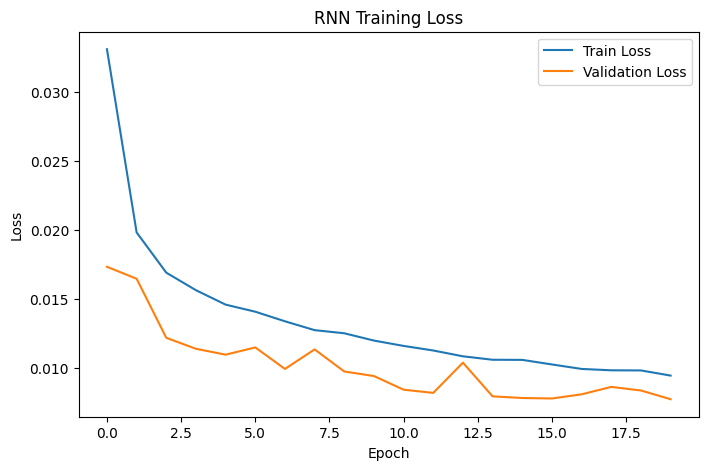

In [15]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')

plt.title('RNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [16]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(SEQ_LEN, X.shape[2]),
        activation='tanh'
    )
)

# Bonus: Dropout Layer
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [18]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - loss: 0.0345 - val_loss: 0.0189
Epoch 2/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.0213 - val_loss: 0.0144
Epoch 3/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - loss: 0.0172 - val_loss: 0.0125
Epoch 4/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0155 - val_loss: 0.0100
Epoch 5/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0139 - val_loss: 0.0088
Epoch 6/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 0.0126 - val_loss: 0.0084
Epoch 7/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.0118 - val_loss: 0.0083
Epoch 8/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - loss: 0.0111 - val_loss: 0.0081
Epoch 9/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.0107 - val_loss: 0.0081
Epoch 10/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - loss: 0.0103 - val_loss: 0.0085
Epoch 11/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - loss: 0.0098 - val_loss: 0.0075
Epoch 12

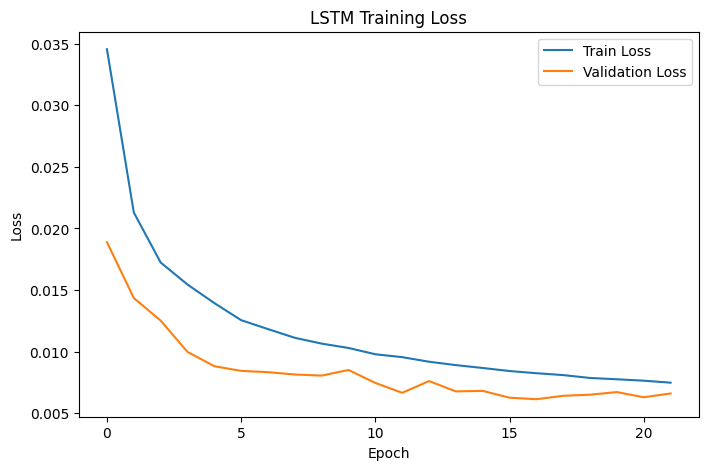

In [19]:
plt.figure(figsize=(8,5))

plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
# RNN Prediction
y_pred_rnn_scaled = rnn_model.predict(X_test)
y_pred_rnn = y_scaler.inverse_transform(y_pred_rnn_scaled)

# LSTM Prediction
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled)

# Original Test Values
y_test_original = y_scaler.inverse_transform(y_test)

226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [21]:
# RNN RMSE
rmse_rnn = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_rnn
    )
)

# LSTM RMSE
rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_lstm
    )
)

print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)

RNN RMSE: 596.9237086096402
LSTM RMSE: 543.2969795016119


In [22]:
# RNN MAE
mae_rnn = mean_absolute_error(
    y_test_original,
    y_pred_rnn
)

# LSTM MAE
mae_lstm = mean_absolute_error(
    y_test_original,
    y_pred_lstm
)

print("RNN MAE:", mae_rnn)
print("LSTM MAE:", mae_lstm)

RNN MAE: 415.8795357504292
LSTM MAE: 371.55828781784044


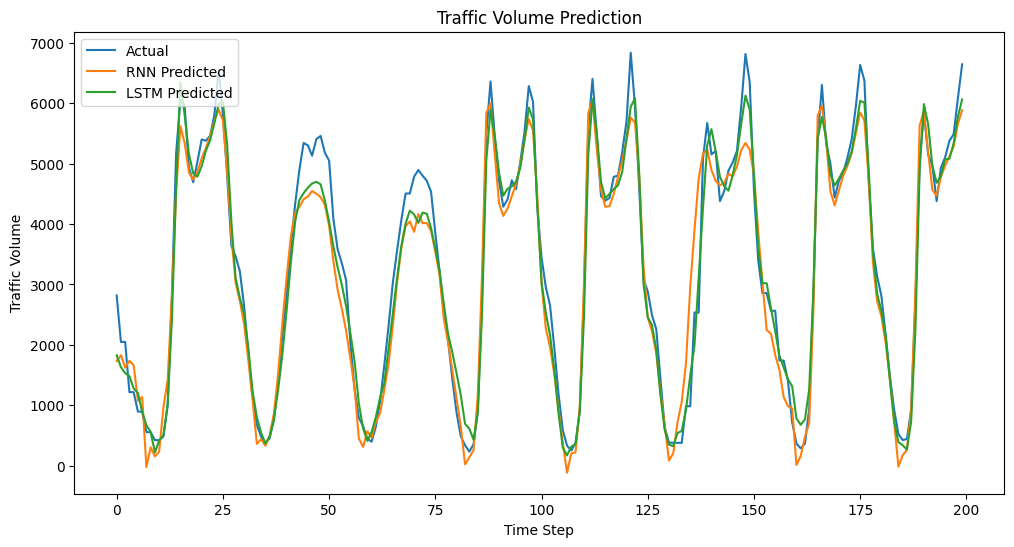

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_original[:200],
    label='Actual'
)

plt.plot(
    y_pred_rnn[:200],
    label='RNN Predicted'
)

plt.plot(
    y_pred_lstm[:200],
    label='LSTM Predicted'
)

plt.title('Traffic Volume Prediction')

plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')

plt.legend()

plt.show()

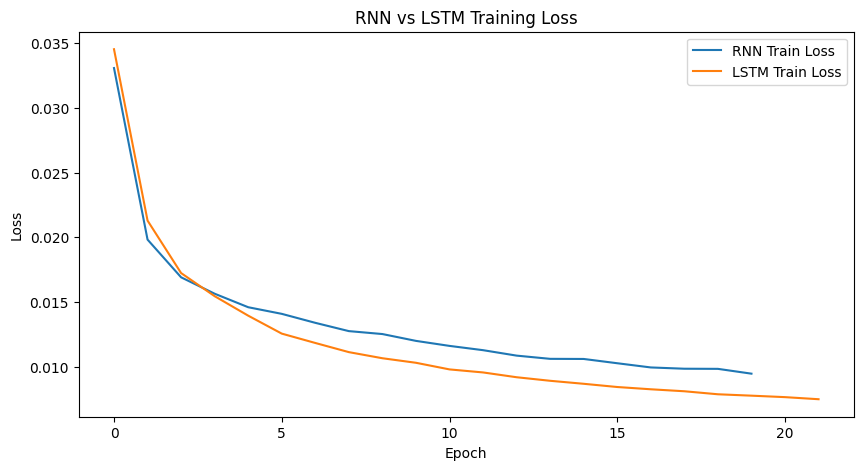

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN Train Loss'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM Train Loss'
)

plt.title('RNN vs LSTM Training Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

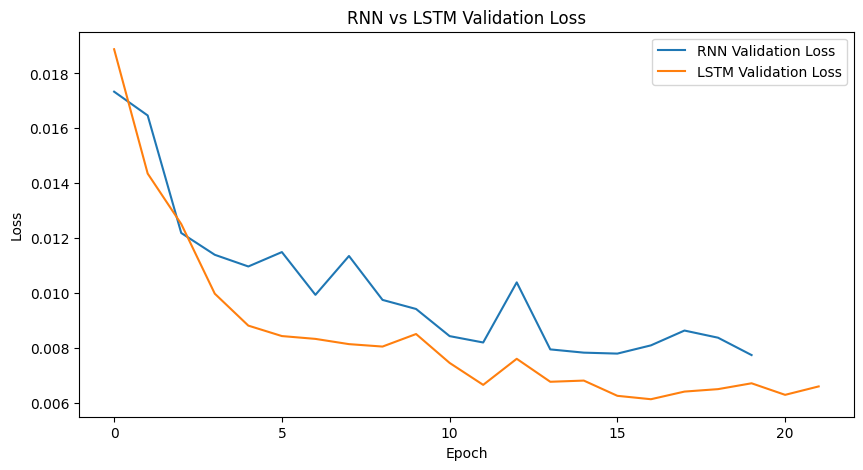

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['val_loss'],
    label='RNN Validation Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='LSTM Validation Loss'
)

plt.title('RNN vs LSTM Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

1. Why do we need sequences in RNN/LSTM?

Answer: RNN and LSTM are designed for sequential data.
Sequences help the model learn patterns over time.

Example:

a.Previous traffic conditions help predict future traffic volume.

b.Previous stock prices help predict future prices.

Without sequences, the model cannot understand time dependency.

2. What is the main limitation of RNN?

Answer: The main limitation of RNN is the vanishing gradient problem.

When sequences become long:

a.RNN forgets older information.

b.Training becomes difficult.

c.Performance decreases for long-term dependencies.

3. How does LSTM solve this problem?

LSTM uses:

i.Memory Cell

ii.Input Gate

iii.Forget Gate

iv.Output Gate

These components help LSTM:

i.Remember important information for long periods.

ii.Forget unnecessary information.

iii.Handle long-term dependencies effectively.

4. Which model performed better and why?

Answer: LSTM performed better because:

i.It can remember long-term patterns.

ii.It handles sequential dependencies more effectively.

iii.It usually gives lower RMSE and MAE compared to RNN.

RNN is simpler but struggles with long sequences.